# Congress Image Probing Analysis

Load saved probing outputs, visualize portrait-level heatmaps, compare party distributions, and inspect DW-NOMINATE correlations for Congress images across ridge prefixes.

In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

sns.set_context("talk")
sns.set_style("whitegrid")

In [2]:
def load_outputs(ridge_prefix, model_name="qwen3-vl-8b-instruct"):
    scores_path = Path(f"results/{model_name}/congress_images_patch_scores_{ridge_prefix}.pt")
    stats_path = Path(f"results/{model_name}/congress_images_patch_stats_{ridge_prefix}.csv")

    if not scores_path.exists():
        raise FileNotFoundError(f"Missing scores file: {scores_path}")
    if not stats_path.exists():
        raise FileNotFoundError(f"Missing stats file: {stats_path}")

    payload = torch.load(scores_path, map_location="cpu")
    df_stats = pd.read_csv(stats_path)

    print(f"Loaded scores: {scores_path}")
    print(f"Loaded stats : {stats_path}")
    print(f"Num portraits: {len(payload['image_paths'])}")
    print("Metadata:")
    display(pd.Series(payload.get("metadata", {}), name="value"))
    display(df_stats.head())

    required_cols = {"bioguide", "name", "party", "nominate_dim1", "mean_image_token_score"}
    missing = required_cols - set(df_stats.columns)
    if missing:
        raise ValueError(f"Missing expected columns in stats CSV: {sorted(missing)}")

    return payload, df_stats

In [3]:
def get_image_scores_for_index(payload, idx):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]


def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="RdBu_r", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)


def show_heatmap_examples(payload, n=6, seed=7):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No portraits in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        person_name = payload.get("names", [Path(p).stem for p in payload["image_paths"]])[idx]
        party = payload.get("parties", ["Unknown"] * n_total)[idx]
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(payload, idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch")
            continue

        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        lim = max(1e-6, float(np.max(np.abs(heat))))
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="RdBu_r", vmin=-lim, vmax=lim)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{person_name} ({party})")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            f"Overlay (mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

In [4]:
def analyze_party_comparison(df_stats):
    party_order = ["Democrat", "Republican"]
    df_party = df_stats[df_stats["party"].isin(party_order)].copy()
    if df_party.empty:
        raise RuntimeError("No Democrat/Republican rows available.")

    df_party["party"] = pd.Categorical(df_party["party"], categories=party_order, ordered=True)

    party_summary = (
        df_party.groupby("party", as_index=False, observed=True)
        .agg(
            n_images=("mean_image_token_score", "size"),
            mean_of_mean=("mean_image_token_score", "mean"),
            median_of_mean=("mean_image_token_score", "median"),
            std_of_mean=("mean_image_token_score", "std"),
            mean_abs_score=("mean_abs_image_token_score", "mean"),
            mean_num_tokens=("num_image_tokens", "mean"),
        )
        .sort_values("party")
        .reset_index(drop=True)
    )

    display(party_summary)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.boxplot(data=df_party, x="party", y="mean_image_token_score", order=party_order, palette="Set2", ax=axes[0])
    axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[0].set_title("Per-portrait Mean Score by Party")
    axes[0].set_xlabel("Party")
    axes[0].set_ylabel("Mean image-token score")

    sns.violinplot(
        data=df_party,
        x="party",
        y="mean_image_token_score",
        order=party_order,
        inner="quartile",
        palette="Set2",
        ax=axes[1],
    )
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title("Distribution Shape by Party")
    axes[1].set_xlabel("Party")
    axes[1].set_ylabel("Mean image-token score")

    sns.barplot(data=party_summary, x="party", y="n_images", order=party_order, palette="Set2", ax=axes[2])
    axes[2].set_title("Portrait Count by Party")
    axes[2].set_xlabel("Party")
    axes[2].set_ylabel("Number of portraits")

    plt.tight_layout()
    plt.show()

    q = (
        df_party.groupby("party", observed=True)["mean_image_token_score"]
        .quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        .unstack()
        .rename(columns={0.05: "q05", 0.25: "q25", 0.5: "q50", 0.75: "q75", 0.95: "q95"})
        .reset_index()
        .sort_values("party")
    )
    display(q)

    return df_party, party_summary

In [5]:
def analyze_statistical_inference(df_party):
    dem = df_party.loc[df_party["party"] == "Democrat", "mean_image_token_score"].dropna().to_numpy()
    rep = df_party.loc[df_party["party"] == "Republican", "mean_image_token_score"].dropna().to_numpy()

    if len(dem) < 2 or len(rep) < 2:
        raise RuntimeError("Not enough samples per party for inference tests.")

    t_stat, t_p = scipy_stats.ttest_ind(dem, rep, equal_var=False)
    u_stat, u_p = scipy_stats.mannwhitneyu(dem, rep, alternative="two-sided")

    mean_diff = float(rep.mean() - dem.mean())
    pooled_sd = float(np.sqrt(((len(rep) - 1) * rep.var(ddof=1) + (len(dem) - 1) * dem.var(ddof=1)) / (len(rep) + len(dem) - 2)))
    cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

    pairwise = rep[:, None] - dem[None, :]
    cliffs_delta = float((np.sum(pairwise > 0) - np.sum(pairwise < 0)) / pairwise.size)

    rng = np.random.default_rng(42)
    n_boot = 5000
    boot_diffs = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        rep_s = rng.choice(rep, size=len(rep), replace=True)
        dem_s = rng.choice(dem, size=len(dem), replace=True)
        boot_diffs[i] = rep_s.mean() - dem_s.mean()
    ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])

    results = pd.DataFrame(
        [
            {"metric": "n_democrat", "value": len(dem)},
            {"metric": "n_republican", "value": len(rep)},
            {"metric": "mean_diff_rep_minus_dem", "value": mean_diff},
            {"metric": "mean_diff_bootstrap_ci_low", "value": float(ci_low)},
            {"metric": "mean_diff_bootstrap_ci_high", "value": float(ci_high)},
            {"metric": "welch_t_stat", "value": float(t_stat)},
            {"metric": "welch_t_pvalue", "value": float(t_p)},
            {"metric": "mannwhitney_u_stat", "value": float(u_stat)},
            {"metric": "mannwhitney_u_pvalue", "value": float(u_p)},
            {"metric": "cohens_d", "value": float(cohens_d)},
            {"metric": "cliffs_delta", "value": float(cliffs_delta)},
        ]
    )
    display(results)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    sns.histplot(boot_diffs, bins=50, kde=True, color="tab:purple", ax=ax)
    ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
    ax.axvline(ci_low, linestyle=":", color="tab:red", linewidth=2, label=f"2.5% = {ci_low:.4f}")
    ax.axvline(ci_high, linestyle=":", color="tab:red", linewidth=2, label=f"97.5% = {ci_high:.4f}")
    ax.axvline(mean_diff, linestyle="-", color="tab:green", linewidth=2, label=f"Observed diff = {mean_diff:.4f}")
    ax.set_title("Bootstrap Distribution: Mean Difference (Republican - Democrat)")
    ax.set_xlabel("Mean difference")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results

In [6]:
def analyze_dw_nominate(df_stats):
    df_corr = df_stats.dropna(subset=["nominate_dim1", "mean_image_token_score"]).copy()
    if len(df_corr) < 10:
        raise RuntimeError("Too few rows after filtering nominate_dim1 and mean_image_token_score.")

    overall_pearson = float(scipy_stats.pearsonr(df_corr["nominate_dim1"], df_corr["mean_image_token_score"])[0])
    overall_spearman = float(scipy_stats.spearmanr(df_corr["nominate_dim1"], df_corr["mean_image_token_score"])[0])

    party_rows = []
    for party, grp in df_corr.groupby("party"):
        n = len(grp)
        if n >= 3:
            p = float(scipy_stats.pearsonr(grp["nominate_dim1"], grp["mean_image_token_score"])[0])
            s = float(scipy_stats.spearmanr(grp["nominate_dim1"], grp["mean_image_token_score"])[0])
        else:
            p = np.nan
            s = np.nan
        party_rows.append({"party": party, "n": int(n), "pearson_r": p, "spearman_rho": s})

    corr_table = pd.DataFrame(party_rows).sort_values("party").reset_index(drop=True)
    display(corr_table)
    print(f"Overall Pearson r: {overall_pearson:.4f}")
    print(f"Overall Spearman rho: {overall_spearman:.4f}")

    member_agg = (
        df_corr.groupby(["bioguide", "name", "party", "nominate_dim1"], as_index=False)
        .agg(
            n_images=("mean_image_token_score", "size"),
            mean_image_score=("mean_image_token_score", "mean"),
            std_image_score=("mean_image_token_score", "std"),
        )
        .sort_values("n_images", ascending=False)
        .reset_index(drop=True)
    )

    pearson_m_r = float(scipy_stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_image_score"])[0])
    spearman_m_rho = float(scipy_stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_image_score"])[0])

    member_corr_table = pd.DataFrame(
        [
            {"metric": "member_level_n", "value": len(member_agg)},
            {"metric": "member_level_pearson_r", "value": pearson_m_r},
            {"metric": "member_level_spearman_rho", "value": spearman_m_rho},
        ]
    )
    display(member_corr_table)

    party_palette = {"Democrat": "#1f77b4", "Republican": "#d62728", "Other (328)": "#2ca02c"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140, constrained_layout=True)

    sns.scatterplot(
        data=df_corr,
        x="nominate_dim1",
        y="mean_image_token_score",
        hue="party",
        palette=party_palette,
        alpha=0.75,
        s=45,
        ax=axes[0],
    )
    sns.regplot(
        data=df_corr,
        x="nominate_dim1",
        y="mean_image_token_score",
        scatter=False,
        color="black",
        line_kws={"linewidth": 2.0},
        ax=axes[0],
    )
    axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[0].set_title(
        f"Pooled correlation\nPearson r={overall_pearson:.3f}, Spearman rho={overall_spearman:.3f}"
    )
    axes[0].set_xlabel("DW-NOMINATE dim1")
    axes[0].set_ylabel("Mean image-token score")

    for party, grp in df_corr.groupby("party"):
        color = party_palette.get(party, None)
        if len(grp) >= 2:
            sns.regplot(
                data=grp,
                x="nominate_dim1",
                y="mean_image_token_score",
                scatter=True,
                ci=None,
                scatter_kws={"alpha": 0.55, "s": 35},
                line_kws={"linewidth": 2.2},
                color=color,
                ax=axes[1],
                label=party,
            )
        else:
            axes[1].scatter(
                grp["nominate_dim1"],
                grp["mean_image_token_score"],
                color=color,
                alpha=0.7,
                s=35,
                label=party,
            )

    axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[1].set_title("Party-specific regression lines")
    axes[1].set_xlabel("DW-NOMINATE dim1")
    axes[1].set_ylabel("Mean image-token score")
    axes[1].legend(loc="best", title="party")

    plt.show()

    display(member_agg.head(20))
    return df_corr, member_agg


  Ridge prefix: politician

Loaded scores: results/qwen3-vl-8b-instruct/congress_images_patch_scores_politician.pt
Loaded stats : results/qwen3-vl-8b-instruct/congress_images_patch_stats_politician.csv
Num portraits: 550
Metadata:


model_path              /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                           data/congress_images
ridge_prefix                                                  politician
top_k                                                                 16
prompt                           What's his/her position on US politics?
resized_image_width                                                  250
max_new_tokens                                                         1
num_portraits_input                                                  550
num_portraits_scored                                                 550
num_skipped_mismatch                                                   0
Name: value, dtype: object

,bioguide,name,party,party_code,nominate_dim1,resized_width,resized_height,grid_h,grid_w,num_image_tokens,mean_image_token_score,median_image_token_score,mean_abs_image_token_score,min_image_token_score,max_image_token_score
0,R000575,Mike Rogers,Republican,200,0.377,250,306,10,8,80,-0.088993,-0.147804,0.208732,-0.516083,0.475950
1,S001185,Terri A. Sewell,Democrat,100,-0.398,250,306,10,8,80,-0.399457,-0.378917,0.400708,-0.963846,0.025747
2,R000591,Martha Roby,Republican,200,0.362,250,306,10,8,80,-0.213726,-0.215703,0.228981,-0.631178,0.213021
3,B001274,Mo Brooks,Republican,200,0.652,250,306,10,8,80,-0.074091,-0.107909,0.199998,-0.448611,0.472756
4,B001289,Bradley Byrne,Republican,200,0.610,250,280,9,8,72,-0.137690,-0.163466,0.209150,-0.577572,0.359214


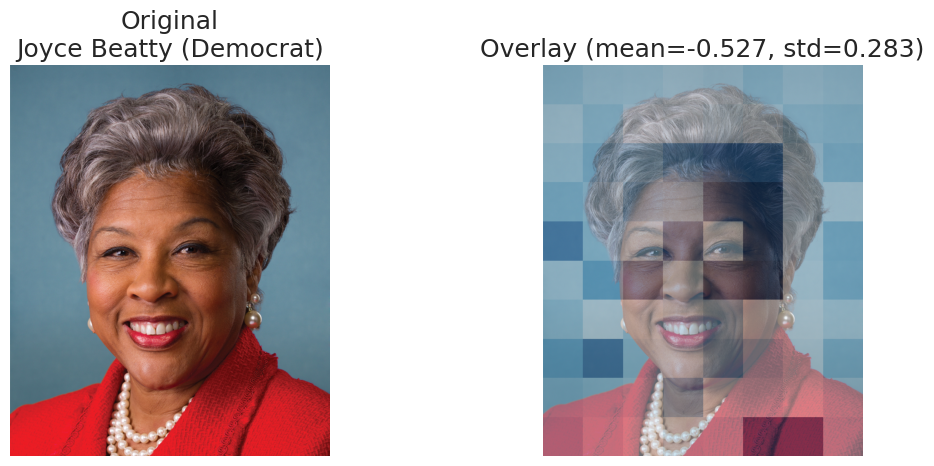

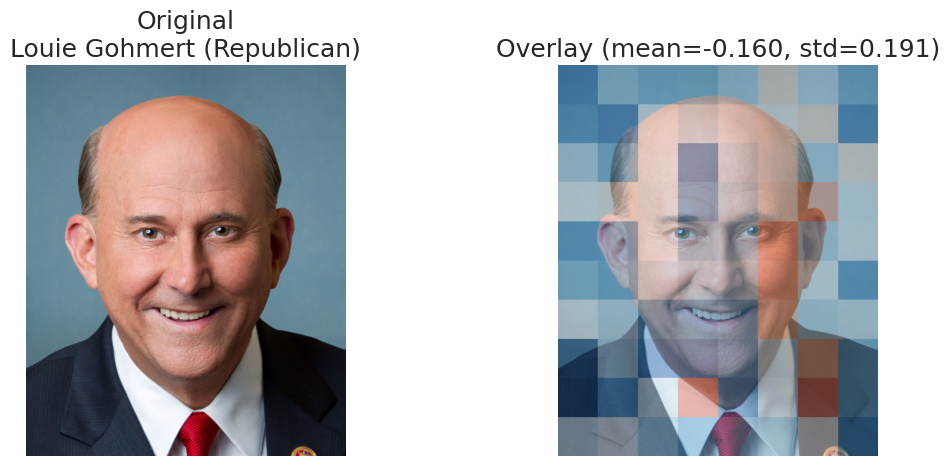

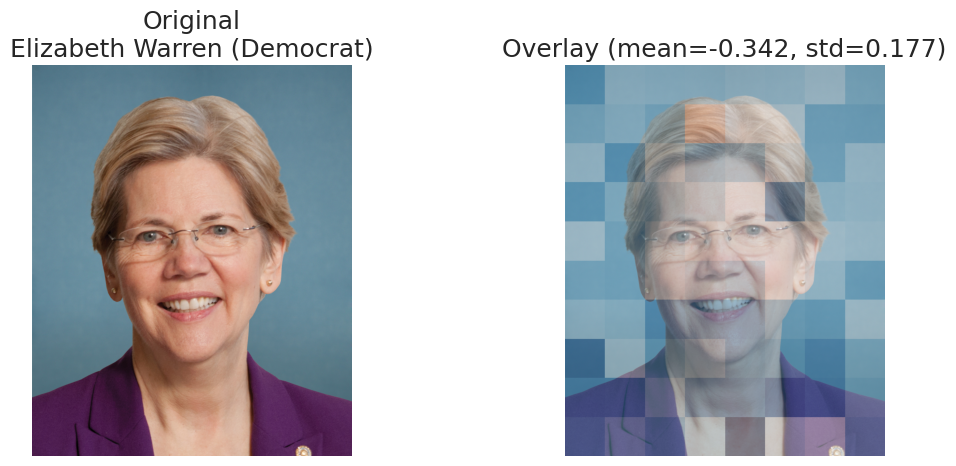

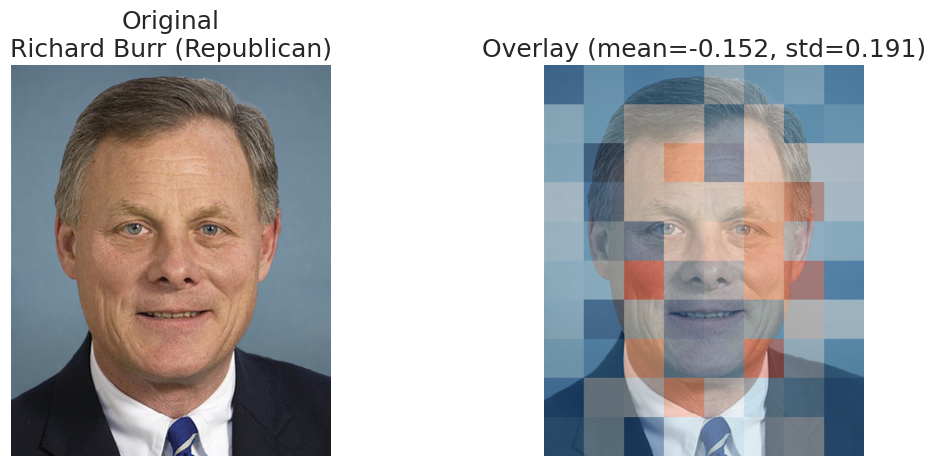

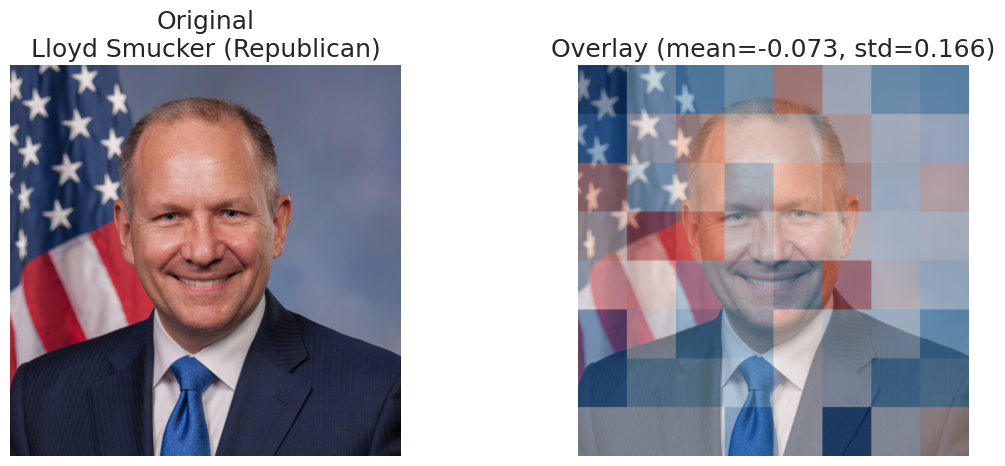

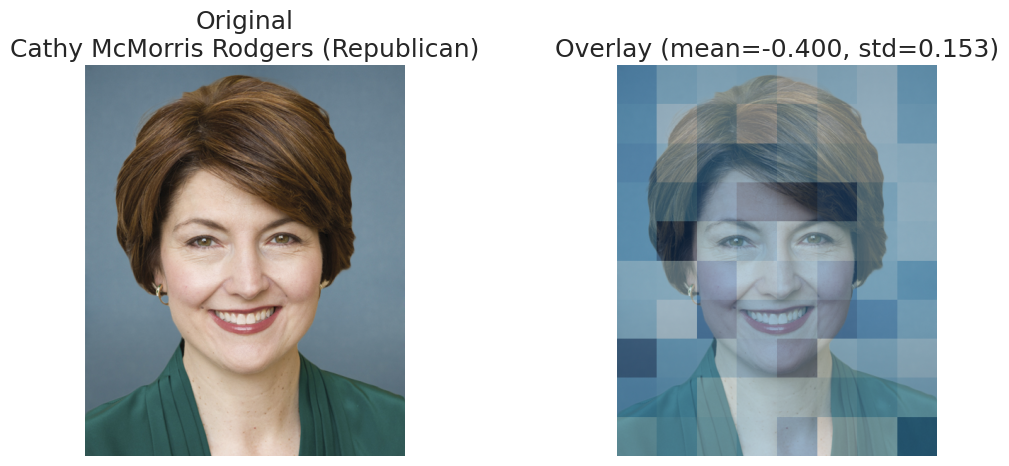

,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_abs_score,mean_num_tokens
0,Democrat,285,-0.273285,-0.259162,0.131194,0.302549,79.157895
1,Republican,262,-0.147123,-0.137745,0.091783,0.218843,79.213740


/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean_image_token_score", order=party_order, palette="Set2", ax=axes[0])
/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", order=party_order, palette="Set2", ax=axes[2])


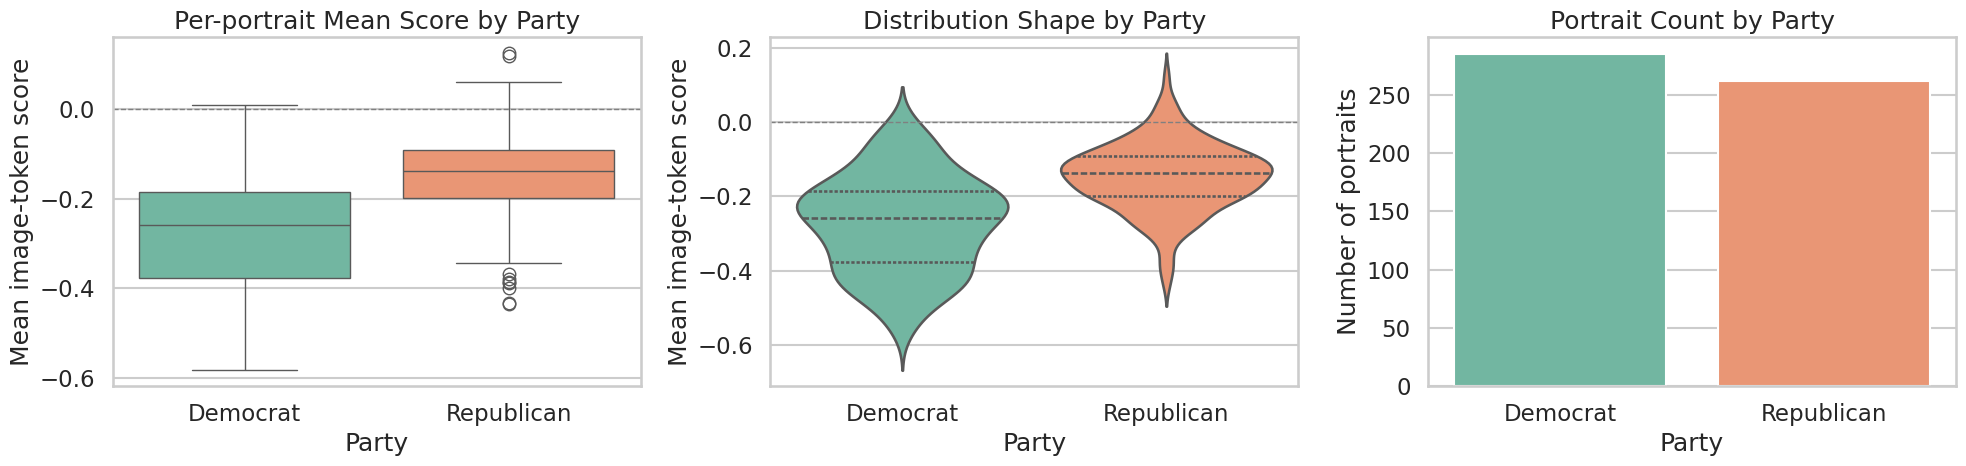

,party,q05,q25,q50,q75,q95
0,Democrat,-0.480222,-0.377103,-0.259162,-0.184221,-0.051409
1,Republican,-0.297935,-0.199183,-0.137745,-0.089905,-0.011520


,metric,value
0,n_democrat,2.850000e+02
1,n_republican,2.620000e+02
2,mean_diff_rep_minus_dem,1.261618e-01
3,mean_diff_bootstrap_ci_low,1.072430e-01
4,mean_diff_bootstrap_ci_high,1.449863e-01
5,welch_t_stat,-1.311448e+01
6,welch_t_pvalue,4.615676e-34
7,mannwhitney_u_stat,1.633350e+04
8,mannwhitney_u_pvalue,5.712774e-30
9,cohens_d,1.106369e+00


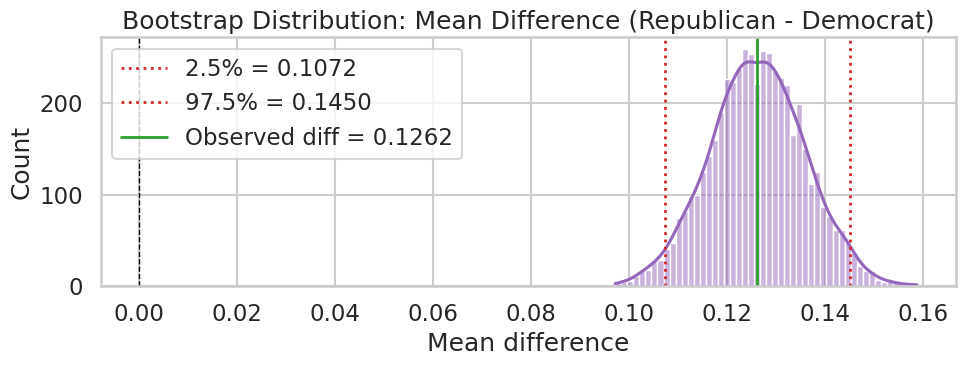

,party,n,pearson_r,spearman_rho
0,Democrat,285,0.384404,0.380257
1,Other (328),3,0.818551,1.000000
2,Republican,262,0.172132,0.131091


Overall Pearson r: 0.5371
Overall Spearman rho: 0.5434


,metric,value
0,member_level_n,550.000000
1,member_level_pearson_r,0.537097
2,member_level_spearman_rho,0.543437


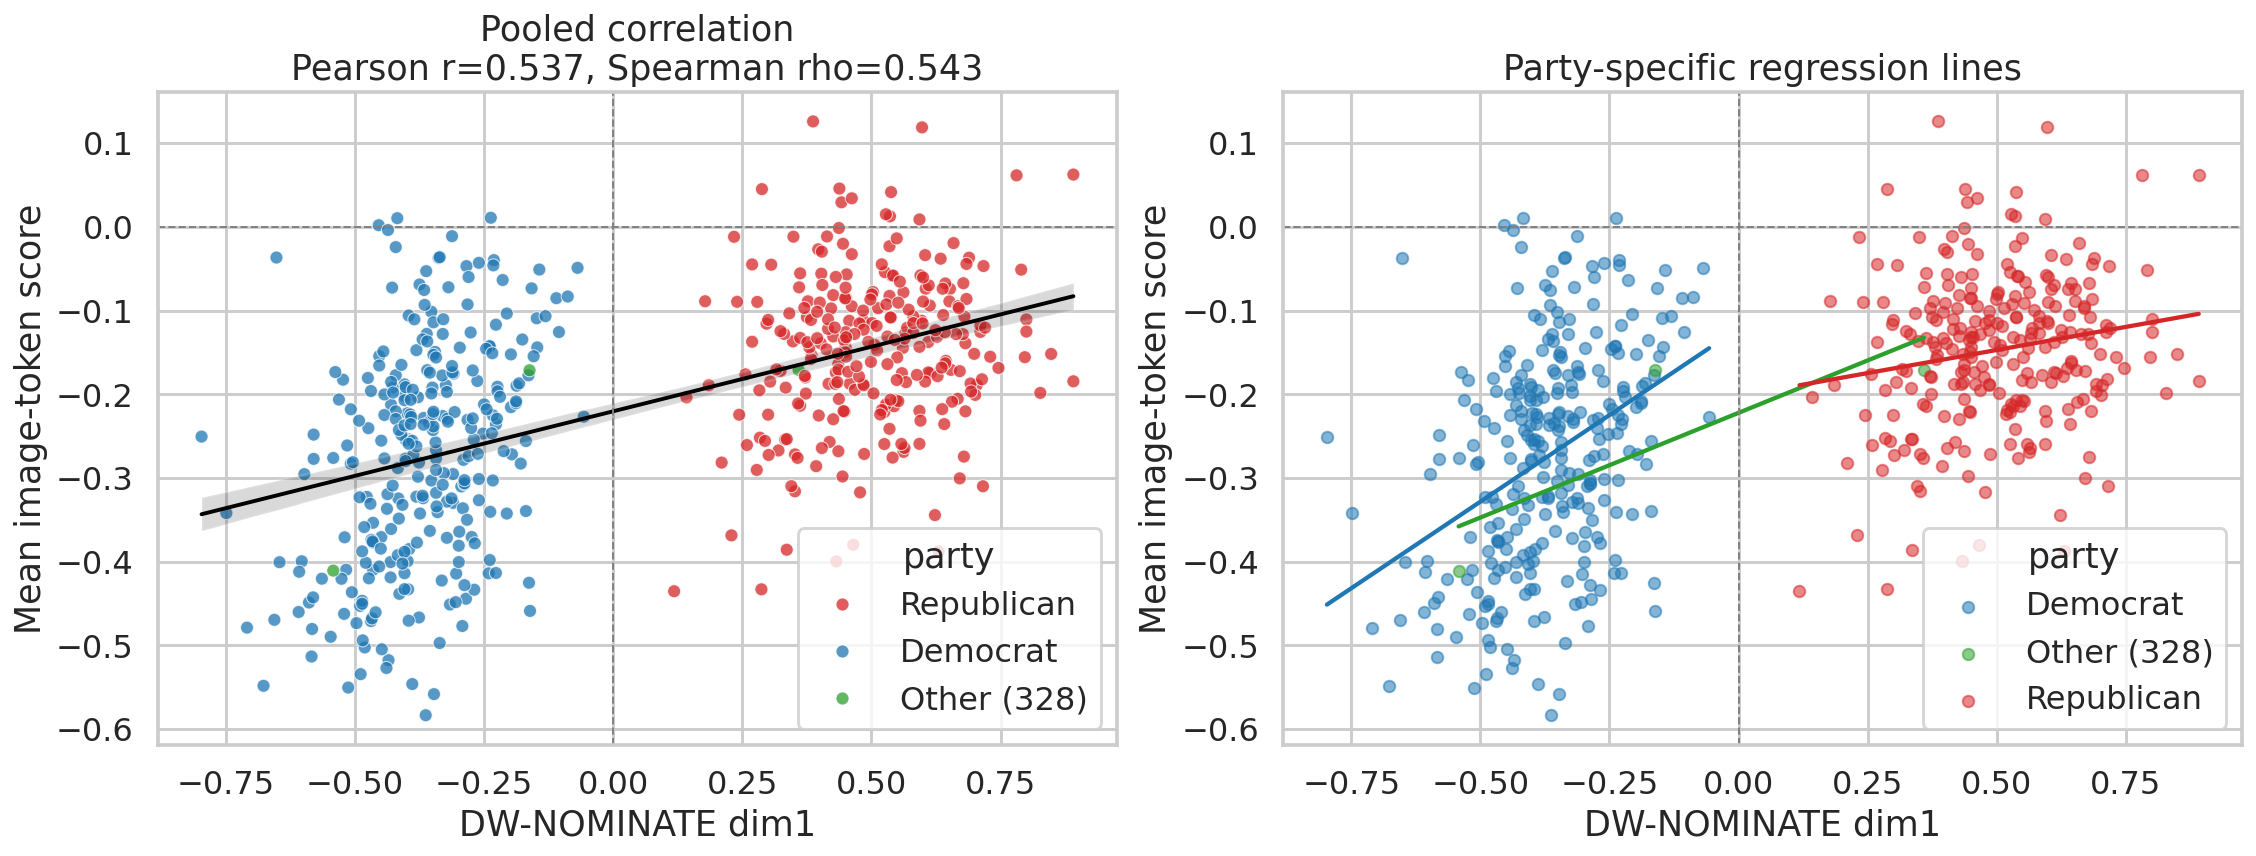

,bioguide,name,party,nominate_dim1,n_images,mean_image_score,std_image_score
0,A000055,Robert B. Aderholt,Republican,0.403,1,-0.055960,NaN
1,A000360,Lamar Alexander,Republican,0.324,1,-0.124668,NaN
2,A000367,Justin Amash,Other (328),0.359,1,-0.170923,NaN
3,A000367,Justin Amash,Republican,0.654,1,-0.170923,NaN
4,A000369,Mark E. Amodei,Republican,0.387,1,0.125974,NaN
5,A000370,Alma S. Adams,Democrat,-0.468,1,-0.373977,NaN
6,A000371,Pete Aguilar,Democrat,-0.310,1,-0.295417,NaN
7,A000372,Rick W. Allen,Republican,0.692,1,-0.187258,NaN
8,A000374,Ralph Lee Abraham,Republican,0.541,1,-0.275760,NaN
9,A000375,Jodey C. Arrington,Republican,0.642,1,-0.125909,NaN



  Ridge prefix: combined_ideology

Loaded scores: results/qwen3-vl-8b-instruct/congress_images_patch_scores_combined_ideology.pt
Loaded stats : results/qwen3-vl-8b-instruct/congress_images_patch_stats_combined_ideology.csv
Num portraits: 550
Metadata:


model_path              /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                           data/congress_images
ridge_prefix                                           combined_ideology
top_k                                                                 16
prompt                           What's his/her position on US politics?
resized_image_width                                                  250
max_new_tokens                                                         1
num_portraits_input                                                  550
num_portraits_scored                                                 550
num_skipped_mismatch                                                   0
Name: value, dtype: object

,bioguide,name,party,party_code,nominate_dim1,resized_width,resized_height,grid_h,grid_w,num_image_tokens,mean_image_token_score,median_image_token_score,mean_abs_image_token_score,min_image_token_score,max_image_token_score
0,R000575,Mike Rogers,Republican,200,0.377,250,306,10,8,80,0.340106,0.280252,0.485308,-0.630625,1.670715
1,S001185,Terri A. Sewell,Democrat,100,-0.398,250,306,10,8,80,-0.328305,-0.328224,0.356261,-0.980392,0.308796
2,R000591,Martha Roby,Republican,200,0.362,250,306,10,8,80,-0.140389,-0.095534,0.283827,-0.903695,0.448334
3,B001274,Mo Brooks,Republican,200,0.652,250,306,10,8,80,0.430689,0.346692,0.563412,-0.722624,1.852140
4,B001289,Bradley Byrne,Republican,200,0.610,250,280,9,8,72,0.263087,0.169717,0.432914,-0.672383,1.515360


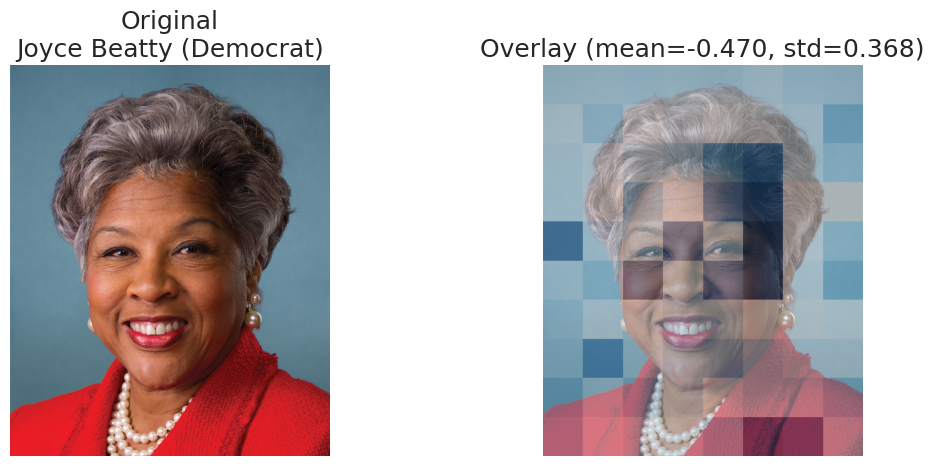

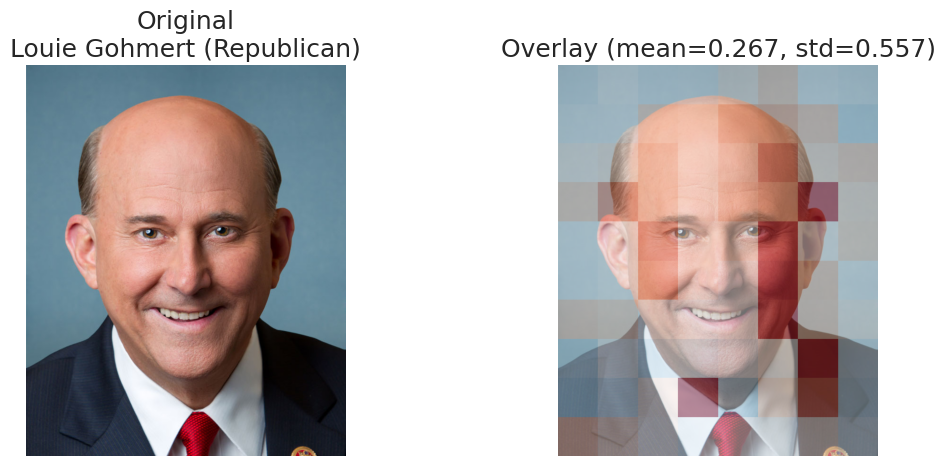

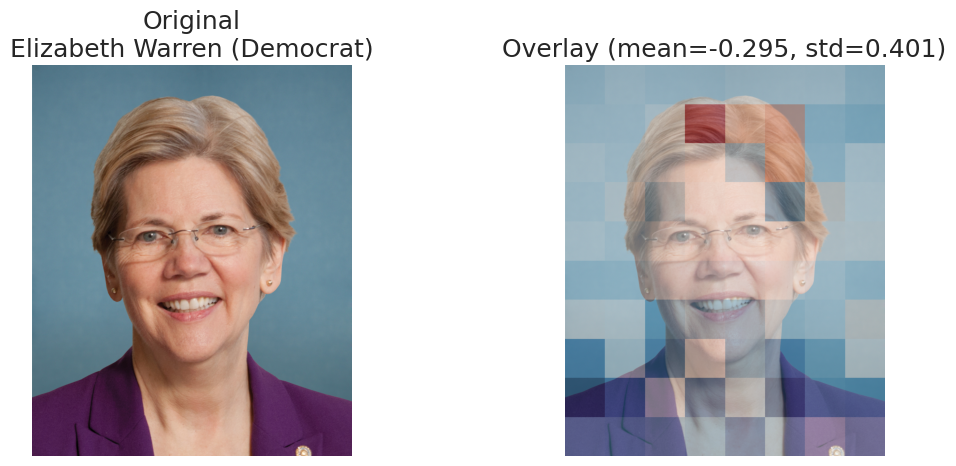

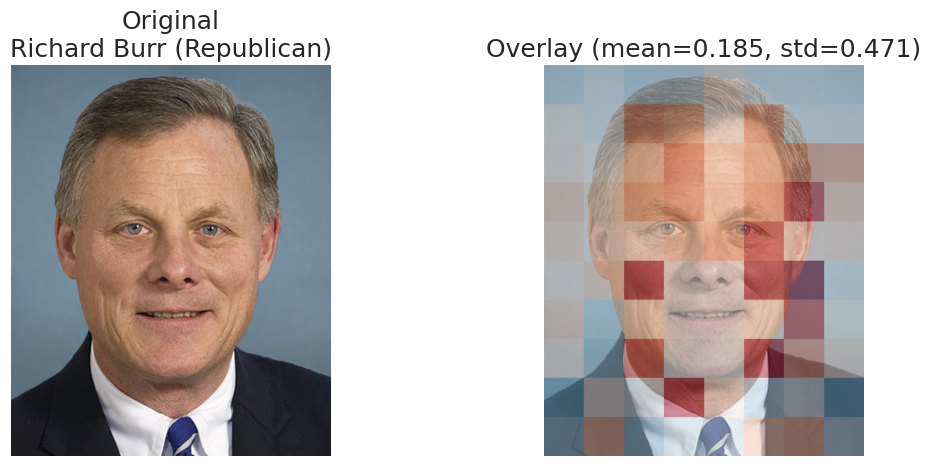

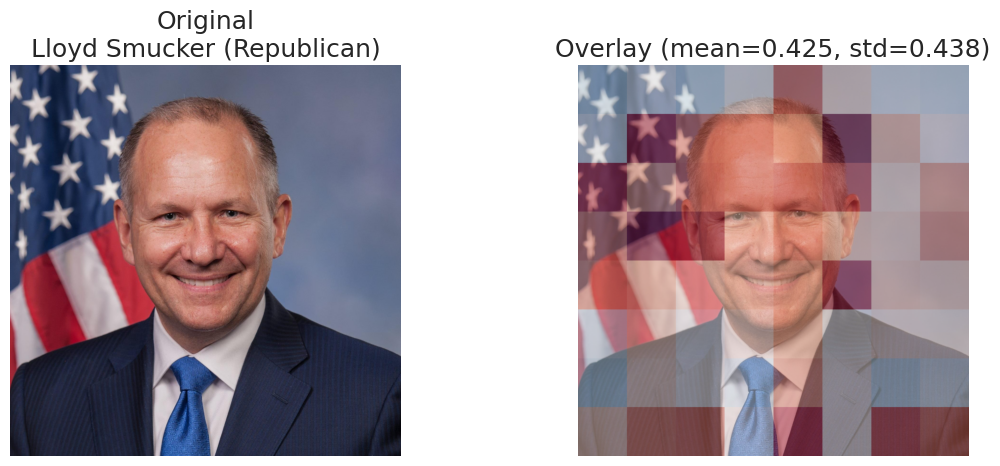

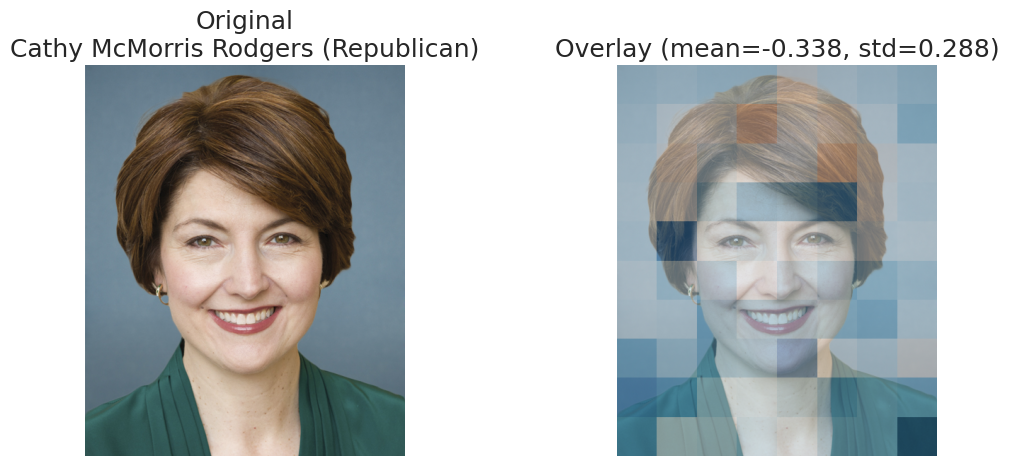

,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_abs_score,mean_num_tokens
0,Democrat,285,-0.081053,-0.067285,0.258083,0.365316,79.157895
1,Republican,262,0.184220,0.198863,0.188479,0.389754,79.213740


/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean_image_token_score", order=party_order, palette="Set2", ax=axes[0])
/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/scratch/local/jobs/48820731/ipykernel_1379469/4198474997.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", order=party_order, palette="Set2", ax=axes[2])


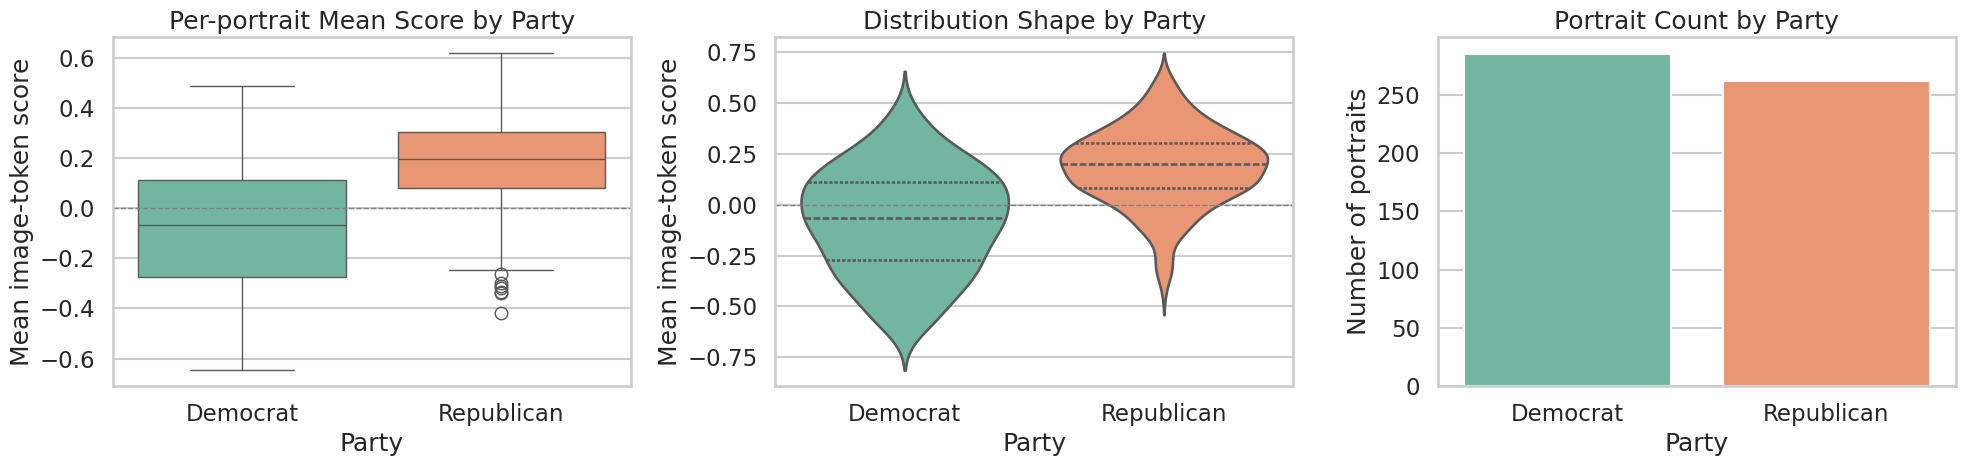

,party,q05,q25,q50,q75,q95
0,Democrat,-0.526803,-0.273354,-0.067285,0.113330,0.315868
1,Republican,-0.131377,0.082244,0.198863,0.304117,0.487768


,metric,value
0,n_democrat,2.850000e+02
1,n_republican,2.620000e+02
2,mean_diff_rep_minus_dem,2.652730e-01
3,mean_diff_bootstrap_ci_low,2.269564e-01
4,mean_diff_bootstrap_ci_high,3.026988e-01
5,welch_t_stat,-1.380398e+01
6,welch_t_pvalue,3.828144e-37
7,mannwhitney_u_stat,1.558550e+04
8,mannwhitney_u_pvalue,5.076262e-32
9,cohens_d,1.166425e+00


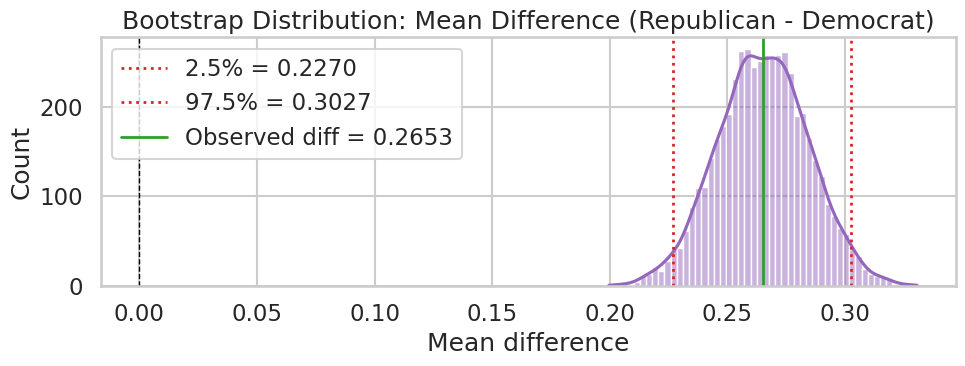

,party,n,pearson_r,spearman_rho
0,Democrat,285,0.367964,0.365782
1,Other (328),3,0.829077,1.000000
2,Republican,262,0.196538,0.174442


Overall Pearson r: 0.5550
Overall Spearman rho: 0.5598


,metric,value
0,member_level_n,550.000000
1,member_level_pearson_r,0.554959
2,member_level_spearman_rho,0.559773


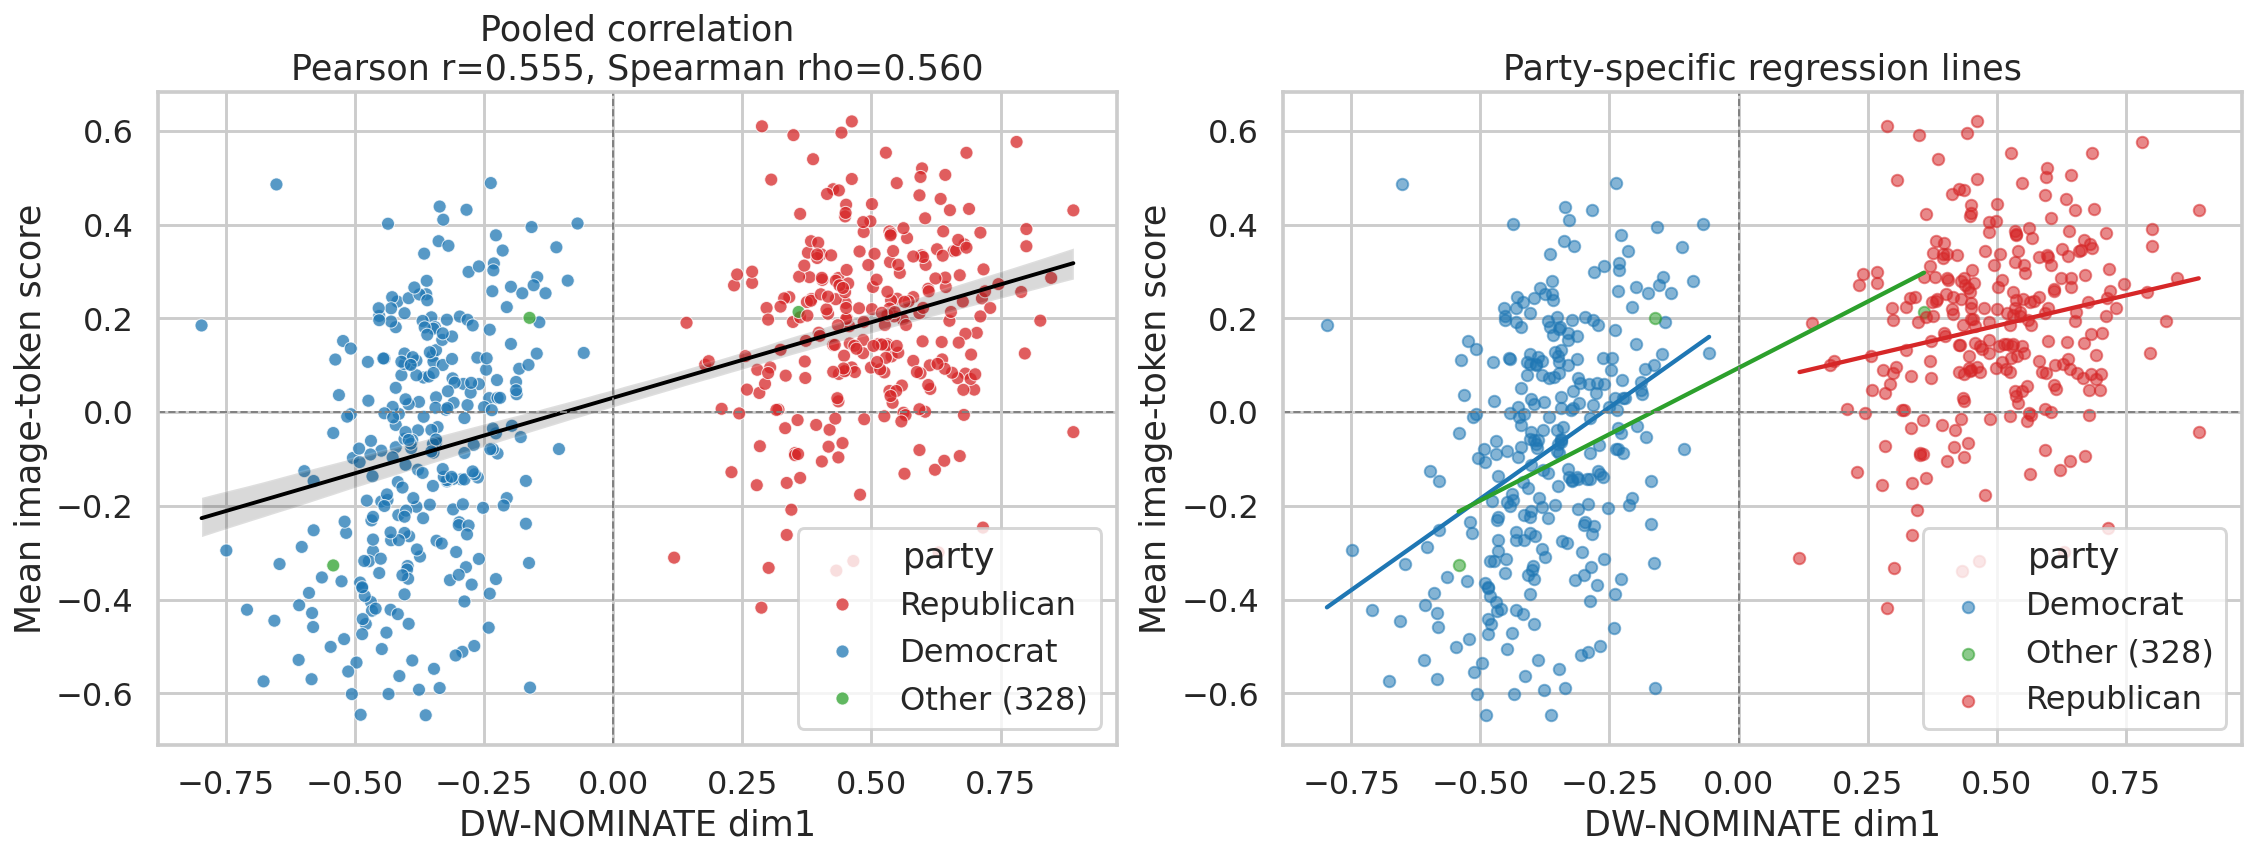

,bioguide,name,party,nominate_dim1,n_images,mean_image_score,std_image_score
0,A000055,Robert B. Aderholt,Republican,0.403,1,0.336510,NaN
1,A000360,Lamar Alexander,Republican,0.324,1,0.224957,NaN
2,A000367,Justin Amash,Other (328),0.359,1,0.213626,NaN
3,A000367,Justin Amash,Republican,0.654,1,0.213626,NaN
4,A000369,Mark E. Amodei,Republican,0.387,1,0.539460,NaN
5,A000370,Alma S. Adams,Democrat,-0.468,1,-0.231070,NaN
6,A000371,Pete Aguilar,Democrat,-0.310,1,-0.207570,NaN
7,A000372,Rick W. Allen,Republican,0.692,1,0.070776,NaN
8,A000374,Ralph Lee Abraham,Republican,0.541,1,0.019817,NaN
9,A000375,Jodey C. Arrington,Republican,0.642,1,0.092407,NaN


In [7]:
def run_all(ridge_prefix, model_name="qwen3-vl-8b-instruct", n_heatmap=6, seed=7):
    print(f"\n{'='*60}")
    print(f"  Ridge prefix: {ridge_prefix}")
    print(f"{'='*60}\n")

    payload, df_stats = load_outputs(ridge_prefix, model_name=model_name)
    show_heatmap_examples(payload, n=n_heatmap, seed=seed)
    df_party, party_summary = analyze_party_comparison(df_stats)
    infer_results = analyze_statistical_inference(df_party)
    df_corr, member_agg = analyze_dw_nominate(df_stats)

    return {
        "payload": payload,
        "df_stats": df_stats,
        "df_party": df_party,
        "party_summary": party_summary,
        "infer_results": infer_results,
        "df_corr": df_corr,
        "member_agg": member_agg,
    }


results_by_prefix = {}
for prefix in ["politician", "combined_ideology"]:
    results_by_prefix[prefix] = run_all(prefix)